# 📖 Agent 實作範例：課程內容自動生成

https://teaching.monster/rules

## 草圖生成

這一步是一個簡單的pipeline

In [ ]:
import os
import requests
from textwrap import dedent

os.chdir("../../")

from langchain_ollama import ChatOllama
from initialization import credential_init

credential_init()

model_blueprint = ChatOllama(model='deepseek-v4-pro:cloud',
                             base_url='https://ollama.com',
                             name='blueprint', temperature=0)

In [ ]:
PHYSICS_SYSTEM_PROMPT = dedent("""\
# ROLE
You are an expert Physics Educator and Instructional Designer specializing in the high-rigor frameworks of IB and AP Physics. Your expertise lies in "Variable Support, Fixed Standards": maintaining absolute academic rigor while dynamically adjusting the conceptual ramp-up based on the student's unique profile.

# INPUT
- `<COURSE_REQUIREMENT>`: The specific physics topic, law, or phenomenon.
- `<STUDENT_PERSONA>`: Student background, grade level, and scientific preparation.

# GOAL
Create a comprehensive PowerPoint teaching blueprint that builds deep conceptual intuition and physical reasoning, culminating in full mathematical rigor. You must ensure the final "Destination" (the level of difficulty and precision) is strictly aligned with AP/IB standards, while the "Path" (the scaffolding and speed of delivery) is perturbed based on the `<STUDENT_PERSONA>`.

# TASK
Generate a `LessonBlueprint` following the structured schema. Synthesize the lesson into a cohesive `slides` sequence incorporating:
1. **The Hook**: An introductory sequence using real-world observations, paradoxes, or thought experiments.
2. **The Conceptual Bridge**: A progressive development of the physics concept. The length and depth of this section must be calibrated to the student's persona.
3. **The Formalization**: Transition from intuition to the formal mathematical laws and equations.
4. **Final Synthesis & Mastery**: A concluding section that ties the laws into a "big picture" and a final high-level challenge problem that matches the full AP/IB difficulty.

# PEDAGOGICAL LOGIC: VARIABLE PATH, FIXED DESTINATION
## 1. Fixed Destination (The Standard)
Regardless of the persona, the final output must meet these non-negotiable standards:
- **Mathematical Rigor**: Use the full, non-simplified versions of laws and equations.
- **Technical Precision**: Use official scientific terminology (e.g., "Centripetal Force" instead of "Center-seeking force").
- **Complexity**: The final challenge problem must require the same multi-step reasoning expected in an AP/IB exam.

## 2. Variable Path (The Perturbation)
Adjust the "ramp-up" based on the `<STUDENT_PERSONA>`:
- **High Readiness**: Fast-track the intuition. Use concise "Quick Recall" hints instead of long explanations. Move toward formalism quickly to maintain engagement.
- **Identified Gaps**: Implement a slower "Conceptual Bridge." Use more analogies, visual scaffolding, and a step-by-step build-up from qualitative to quantitative. **CRITICAL**: If a slide introduces knowledge that is explicitly identified as a gap in the student's profile, you must use 1-2 preceding slides to bridge and fill this gap before proceeding.
- **Learning Style**: For conceptual learners, emphasize the "Why" through more visual reasoning; for mathematical learners, use the math to derive the intuition.

# RULES
## 1. Cognitive Load & Slide Distribution
- **No "Wall of Text"**: Avoid overly long `speaker_notes`. Each slide should focus on a single core concept or step of the derivation.
- **Slide Splitting**: If a concept, explanation, or mathematical derivation is lengthy or complex, **do not** cram it into one slide. Instead, break it into multiple slides to maintain a steady cognitive load and keep the student engaged.
- **Brevity**: Keep `speaker_notes` concise and conversational. If the narration exceeds 3-4 short paragraphs, it is a signal to split the slide.

## 2. Global Consistency & Dataset
- **Global Dataset**: Define a consistent physical scenario (e.g., specific masses, circuits, or distances) at the start. All slides must refer to this same dataset to ensure narrative continuity.
- **Narrative Flow**: Each slide must logically lead to the next via a bridging `transition_to_next`.

## 3. Field Specifications
- `slide_content`: Concise bullet points. Use LaTeX for all mathematical and physical notation.
- `speaker_notes`: Conversational, engaging narration. Explain the intuition and guide the student's eye through the visuals. Keep them tight and focused.

# CHAIN OF THOUGHT
1. **Define the Destination**: Identify the exact AP/IB rigor required for the `<COURSE_REQUIREMENT>`.
2. **Analyze the Persona**: Determine the "Cognitive Gap" between the `<STUDENT_PERSONA>` and the destination.
3. **Calibrate the Path**: Determine the necessary "perturbation" (e.g., "Slower ramp-up needed for vector prerequisites" or "Fast-track intuition due to high math readiness").
4. **Design the Global Dataset**: Create a versatile scenario that can scale from simple intuition to complex calculation.
5. **Map the Teaching Arc**: Sequence the `SlideBase`, `PuzzleSlide`, `ConceptCheckSlide`, and `AlgorithmWalkthroughSlide`. 
6. **Optimize Slide Density**: Review the planned content. If any slide feels too "heavy" (either in bullet points or speaker notes), split it into two or more slides to ensure a smooth pedagogical flow.
7. **Verify Rigor**: Ensure that despite the persona-based support, the final slides achieve the full required academic standard.
""")

In [ ]:
from typing import List, Optional, Union, Literal

from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import PromptTemplate, HumanMessagePromptTemplate, ChatPromptTemplate

class SlideBase(BaseModel):
    slide_number: int = Field(..., description="Slide order in the presentation")
    slide_type: str = Field(..., description="The type of the slide for rendering purposes (e.g., 'base', 'puzzle', 'concept_check', 'algorithm')")
    slide_title: str = Field(
        ...,
        description="<SLIDE_TITLE>. Title displayed at the top of the slide"
    )
    slide_content: List[str] = Field(
        ...,
        description="<SLIDE_CONTENT>. Short bullet points shown on the slide. Keep concise and readable."
    )
    speaker_notes: str = Field(
        ...,
        description="<SPEAKER_NOTES>. Detailed lecture narration for TTS. Explain slide content in conversational teaching style"
    )
    transition_to_next: str = Field(
        ...,
        description="<TRANSITION_TO_NEXT>. One sentence transition connecting this slide to the next concept"
    )


class ConceptCheckSlide(SlideBase):
    slide_type: Literal["concept_check"] = "concept_check"
    question: str = Field(..., description="Conceptual question testing understanding")
    expected_thinking_process: str = Field(..., description="Reasoning students should follow")
    correct_insight: str = Field(..., description="Key conceptual insight behind the answer")


class PuzzleSlide(SlideBase):
    slide_type: Literal["puzzle"] = "puzzle"
    puzzle_question: str = Field(..., description="A surprising or curiosity-inducing question")
    hint: Optional[str] = None
    learning_purpose: str = Field(..., description="Why this puzzle helps learning")


class AlgorithmWalkthroughSlide(SlideBase):
    slide_type: Literal["algorithm"] = "algorithm"
    algorithm_steps: List[str] = Field(..., description="Step-by-step breakdown of the algorithm")
    visualization_description: Optional[str] = Field(None, description="Description of how the algorithm should be visualized")
    key_insight: str = Field(..., description="The critical '\''aha!\'' moment of the algorithm")


class StudentProfileInterpretation(BaseModel):
    inferred_level: str = Field(..., description="Estimated academic level")
    prior_knowledge: List[str] = Field(..., description="What the student likely already knows")
    knowledge_gaps: List[str] = Field(..., description="Potential gaps to scaffold around")
    teaching_adjustments: List[str] = Field(..., description="How explanations will be adapted")


class LessonBlueprint(BaseModel):
    title: str = Field(..., description="Course or lesson title")
    subject: str = Field(..., description="Physics, Biology, Computer Science, or Mathematics")
    target_level: str = Field(..., description="Approximate IB/AP difficulty alignment")
    student_profile: StudentProfileInterpretation
    
    slides: List[
        Union[
            SlideBase,
            ConceptCheckSlide,
            PuzzleSlide,
            AlgorithmWalkthroughSlide
        ]
    ] = Field(
        ..., 
        description="The full sequence of slides. This sequence MUST include: 1. The Teaching Arc (Introduction & Progression), 2. Main Content slides, 3. Final Synthesis, and 4. Challenge Question."
    )

    extension_topic: Optional[str] = Field(
        default=None,
        description="Advanced topic for further exploration"
    )


class Slides(BaseModel):
    slides: List[
        Union[
            SlideBase,
            ConceptCheckSlide,
            PuzzleSlide,
            AlgorithmWalkthroughSlide
        ]
    ]

In [ ]:
output_parser = PydanticOutputParser(pydantic_object=LessonBlueprint)
format_instructions = output_parser.get_format_instructions()

system_message = SystemMessage(content=PHYSICS_SYSTEM_PROMPT)
human_prompt = PromptTemplate(template=dedent("""
                                            <COURSE_REQUIREMENT>: {course_requirement}
                                            <STUDENT_PERSONA>: {student_persona}>
                                        
                                            format_instructions: {format_instructions}
                                            """),
                              input_variables=["course_requirement", "student_persona"],
                              partial_variables={'format_instructions': format_instructions}
                              )
human_message = HumanMessagePromptTemplate(prompt=human_prompt)

chat_prompt = ChatPromptTemplate.from_messages([system_message,
                                                human_message
                                                ])

pipeline_blueprint = chat_prompt | model_blueprint | output_parser

In [ ]:
course_requirement = dedent("""\
Big Concept: Triangle Centers
Topic: Comparing Triangle Centers in Different Contexts
Bloom's Taxonomy: analyze, evaluate
Learning Goal: Analyze: Compare centroid, incenter, and circumcenter
Evaluate: Determine the most appropriate center in different scenarios and justify the reasoning
Key Learning Points: Properties of centroid, incenter, and circumcenter
Distance relationships (to sides vs vertices)
Functional differences of triangle centers
""")

student_persona = dedent("""\
Grade: 9th gradeFocus Time: 15 minutesBackground Knowledge: Has: basic definitions of triangle centersLacks: ability to compare and apply concepts in different contexts
""")


output = pipeline_blueprint.invoke({"course_requirement": course_requirement, "student_persona": student_persona})

In [ ]:
output.model_dump()

看起來有模有樣，但是我們並不能完全相信這個內容

因為:
1. 大語言模型可能生成不準確的內容
2. 大語言模型並不會算數學

所以我們要建立一個Agent來幫我們進行查核並且修正

首先來建立工具

### 回饋 (Feedback)

In [ ]:
from langchain_core.prompts.image import ImagePromptTemplate
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate, PromptTemplate


def build_standard_chat_prompt_template(kwargs):
    messages = []

    if 'system' in kwargs:
        content = kwargs.get('system')

        # allow list of prompts for multimodal
        if isinstance(content, list):
            prompts = [PromptTemplate(**c) for c in content]
        else:
            prompts = [PromptTemplate(**content)]

        message = SystemMessagePromptTemplate(prompt=prompts)
        messages.append(message)

    if 'human' in kwargs:
        content = kwargs.get('human')

        # allow list of prompts for multimodal
        if isinstance(content, list):
            prompts = []
            for c in content:
                if c.get("type") == "image":
                    prompts.append(ImagePromptTemplate(**c))
                else:
                    prompts.append(PromptTemplate(**c))
        else:
            if content.get("type") == "image":
                prompts = [ImagePromptTemplate(**content)]
            else:
                prompts = [PromptTemplate(**content)]

        message = HumanMessagePromptTemplate(prompt=prompts)
        messages.append(message)

    chat_prompt_template = ChatPromptTemplate.from_messages(messages)

    return chat_prompt_template

此 System Prompt 的主要目的是：讓模型扮演「教學品質審核專家」，對使用者的請求（user_query）進行嚴格檢查，確保其在邏輯、格式與教學設計上都是一致且合理的。

核心重點包括：

- 檢查 user_query 是否邏輯一致、沒有矛盾或衝突指令
- 驗證輸出格式要求是否清楚且前後一致
- 確保語言純淨（不得混入非目標語言，例如簡體中文）
- 檢查教學內容（如 slide_content）是否正確，且與 speaker_notes 相互對應
- 確保講解內容沒有脫節或互相矛盾

在教學設計層面，重點是：

- 是否符合學習者的既有知識（避免過度或不足講解）
- 是否有針對知識缺口進行適當補強
- 是否遵守指定的教學風格與調整（語氣、結構、深度等）

最終目標是判斷該 user_query 是否「可以直接使用」來生成高品質教學內容，並在不合格時提供具體改進建議。

In [ ]:
from textwrap import dedent

from langchain.tools import BaseTool, ToolRuntime
from langchain_core.runnables import Runnable
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from pydantic import BaseModel, Field

FEEDBACK_SYSTEM_PROMPT = dedent("""
# ROLE
You are an expert educational evaluator and feedback specialist. Your goal is to analyze a `user_query` to determine if it is self-consistent and adheres to a specific pedagogical profile.

# TASK
You must perform a rigorous check of the `user_query` against the following criteria, ensuring it aligns with the provided Pedagogy Profile (`prior_knowledge`, `knowledge_gaps`, and `teaching_adjustments`).

# EVALUATION CRITERIA
## 1. Self-Consistency & Quality Check
- **Logical Coherence**: Check if the `user_query` contains contradictory instructions or conflicting goals. Ensure the logical flow is coherent.
- **Format Integrity**: If the query asks for a specific output format, verify that it is maintained throughout the request.
- **Language Integrity**: Ensure the `user_query` contains no unintended Simplified Chinese characters or fragments; the query must be entirely in the target language.
- **Content Correctness**: Verify that the information provided in the `slide_content` is accurate and logically sound.
- **Cross-Field Consistency**: Ensure that the `slide_content` and `speaker_notes` are perfectly aligned. The narration in the speaker notes should support and expand upon the bullet points in the slide content without contradicting them or introducing disconnected information.

## 2. Pedagogical Alignment Check
- **Prior Knowledge Alignment**: Verify if the query assumes the student knows what is listed in `prior_knowledge` and avoids over-explaining known concepts.
- **Knowledge Gap Bridging**: Check if the query explicitly or implicitly plans to bridge the identified `knowledge_gaps` using appropriate scaffolding techniques.
- **Teaching Adjustment Adherence**: Ensure the delivery, tone, and structure of the query reflect the requested `teaching_adjustments`.

# OUTPUT FORMAT
Provide your analysis in the following structured format:
- **Consistency Status**: [Consistent / Inconsistent] + Brief reasoning (include any language artifact findings).
- **Pedagogical Alignment**: [Aligned / Misaligned] + Detailed breakdown of how `prior_knowledge`, `knowledge_gaps`, and `teaching_adjustments` were respected or violated.
- **Verdict**: [Pass / Fail]
- **Suggested Improvements**: If "Fail", provide specific instructions on how to modify the `user_query` to align with the pedagogy profile and remove any linguistic artifacts.
""")


class Context(BaseModel):
    # 我們假設這三個生成的結果是正確的，所以不再改動
    prior_knowledge: str
    knowledge_gaps: str
    teaching_adjustments: str

class Inputs(BaseModel):
    user_query: str = Field(description="The content the presentations")


class FeedbackTool(BaseTool):
    input_parser: PydanticOutputParser = PydanticOutputParser(pydantic_object=Inputs)
    input_format_instructions: str = input_parser.get_format_instructions()

    name: str = "Script feedback tool"
    description_template: str = dedent("""\
    Use this tool to check the correctness of the presentation content.
    
    The input contains the presentation content `user_query` for supervision.
    
    input format instructions: {input_format_instructions}
    """)

    description: str = description_template.format(input_format_instructions=input_format_instructions)

    pipeline: Runnable

    @classmethod
    def create(cls, llm: Runnable):

        input_ = {"system": {"template": FEEDBACK_SYSTEM_PROMPT},
                  "human": {"template": dedent("""
                                            SLIDE: {user_query}

                                            PRIOR_KNOWLEDGE: {prior_knowledge}
                                            
                                            KNOWLEDGE_GAP: {knowledge_gaps}
                                            
                                            TEACHING_ADJUSTMENTS: {teaching_adjustments}
                                            """),
                            "input_variable": ["user_query", "prior_knowledge", "knowledge_gaps", "teaching_adjustments"]}}

        chat_prompt_template = build_standard_chat_prompt_template(input_)

        pipeline = chat_prompt_template | llm | StrOutputParser()

        return cls(pipeline=pipeline)

    def _run(self, runtime: ToolRuntime[Context], **input):
        # Handle wrapped input from middleware
        print(f"Running {self.name}...")
        prior_knowledge = runtime.context.prior_knowledge
        knowledge_gaps = runtime.context.knowledge_gaps
        teaching_adjustments = runtime.context.teaching_adjustments

        args = input.get("input", input)
        query = args['user_query']

        result = self.pipeline.invoke({"user_query": query,
                                       "prior_knowledge": prior_knowledge,
                                       'knowledge_gaps': knowledge_gaps,
                                       'teaching_adjustments': teaching_adjustments})
        return result

    async def _arun(self, runtime: ToolRuntime[Context], **input):
        print(f"Running {self.name}...")
        prior_knowledge = runtime.context.prior_knowledge
        knowledge_gaps = runtime.context.knowledge_gaps
        teaching_adjustments = runtime.context.teaching_adjustments

        args = input.get("input", input)
        query = args['user_query']
        
        result = await self.pipeline.ainvoke({"user_query": query,
                                              "prior_knowledge": prior_knowledge,
                                              'knowledge_gaps': knowledge_gaps,
                                              'teaching_adjustments': teaching_adjustments})
        return result

### 微調 (Finetuning)

把這個當作Revision就行

System Prompt 的主要目的是：讓模型扮演「教學設計專家」，根據使用者的回饋，對整份簡報進行全面且一致的優化，而不是只修改單一投影片。

核心重點包括：

- 從整體角度調整內容，確保所有投影片之間邏輯連貫、前後一致
- 在不改變簡報結構與順序的前提下，優化每一頁的內容與講稿
- 確保投影片內容與講者備註彼此對應，互相補充說明
- 維持術語、符號與範例在全簡報中的一致性
- 避免重複講解，讓後續內容建立在前面已介紹的概念之上
- 根據回饋調整深度、風格或錯誤，並將影響同步更新到所有相關頁面
- 確保數學表達正確（使用 LaTeX）且講解自然易懂（適合語音敘述）

總體而言，這個 Prompt 的目標是把簡報打磨成一個「內容一致、邏輯清晰、教學流暢」的完整學習體驗。

In [ ]:
FINETUNING_SYSTEM_PROMPT = dedent("""
# ROLE
You are a Specialized Instructional Designer and Educational Content Architect. Your goal is to refine an entire presentation based on user feedback, ensuring pedagogical consistency and a seamless narrative flow across all slides.

# TASK
You will receive the complete current presentation (a sequence of slides) and a piece of feedback. Your task is to finetune the WHOLE presentation to address the feedback. While you may modify the content of various slides to ensure coherence, the overall structure and sequence of the presentation must remain fixed.

# EDITING RULES
## 1. Global Coherence & Flow
- **Holistic Adjustment**: Do not treat slides in isolation. If a change in Slide 2 affects a concept introduced in Slide 1 or used in Slide 3, you must update all affected slides to maintain a consistent narrative.
- **Fixed Structure**: The total number of slides and the general order of topics must remain unchanged. You are refining the content within the existing structural framework.
- **Narrative Continuity**: Ensure that transitions between slides remain smooth and that the progression of complexity is logical after the edits.
- **Anti-Redundancy**: Speaker notes in later slides must never repeat information, definitions, or explanations that were already established in previous slides. Instead, they should build upon that knowledge (e.g., "As we saw in the previous slide..." or "Building on the concept of X...").

## 2. Intra-Slide Consistency
- **Content-Narration Sync**: Every point made in the `slide_content` must be supported and expanded upon in the `speaker_notes`, and vice-versa. There should be no "phantom" points in the notes that aren't referenced on the slide, nor should the slide contain key points that the speaker completely ignores.
- **Mutual Reinforcement**: The `speaker_notes` should provide the "why" and the "intuition" for the "what" presented in the `slide_content`.

## 3. Global Content Consistency
- **Terminology Stability**: Ensure that the same term, symbol, or variable is used consistently across all slides. Do not switch between synonyms (e.g., "Force" and "Push") unless it serves a specific pedagogical purpose.
- **Dataset Continuity**: If a specific example or numerical value is changed in one slide to address feedback, you must propagate that change across all other slides to prevent contradictions.

## 4. Quality Guardrails (Non-Negotiable)
- **Mathematical Notation**: All math must be in LaTeX. Ensure symbols and notation are consistent across the entire presentation.
- **TTS Narration**: `speaker_notes` must remain conversational, engaging, and intuitive. Avoid simply reading bullet points.
- **Conciseness**: Maintain `slide_content` as short, readable bullet points. Avoid paragraphs on slides.

## 5. Feedback Handling
- **Corrective Feedback**: If an error is identified, fix it and propagate the correction throughout the presentation to avoid contradictions.
- **Stylistic/Pedagogical Feedback**: Adapt the tone, depth, or phrasing across the entire set of slides to ensure a uniform "voice" and level of difficulty.
- **Depth Adjustments**: If the user requests more or less detail, redistribute the information across the existing slides to balance the cognitive load.

# CHAIN OF THOUGHT
1. **Analyze Feedback**: Identify the core issue (Accuracy? Tone? Visuals? Depth? Flow?).
2. **Map Impact**: Determine which slides in the presentation are affected. Identify the "ripple effect"—how a change in one slide necessitates changes in others to keep the narrative intact.
3. **Execute Global Edit**: Rewrite the affected slides, applying the "Quality Guardrails" and the "Intra-Slide Consistency" rules.
4. **Consistency Audit**: Review the entire sequence from start to finish. Check specifically for:
    - Redundancy in `speaker_notes` (do they repeat earlier slides?).
    - Terminology drift (is a term used differently in slide 8 vs slide 2?).
    - Alignment between `slide_content` and `speaker_notes`.
5. **Final Verification**: Ensure the updated presentation is a cohesive, non-redundant, and mathematically valid sequence.
""")


class Inputs(BaseModel):
    user_query: str = Field(description="The content the presentation")
    feedback: str = Field(description="feedback to the presentation")


class FineTuningTool(BaseTool):
    input_parser: PydanticOutputParser = PydanticOutputParser(pydantic_object=Inputs)
    input_format_instructions: str = input_parser.get_format_instructions()

    name: str = "Script finetuning tool"
    description_template: str = dedent("""\
    Use this tool to generate the presentation content
    input format: {input_format_instructions}
    """)

    description: str = description_template.format(input_format_instructions=input_format_instructions)

    pipeline: Runnable

    @classmethod
    def create(cls, llm: Runnable):

        input_ = {"system": {"template": FINETUNING_SYSTEM_PROMPT},
                  "human": {"template": dedent("""
                                            SLIDE: {user_query}
                                            
                                            FEEDBACK: {feedback}
                                            """),
                            "input_variable": ["user_query", "feedback"],
                            }}

        chat_prompt_template = build_standard_chat_prompt_template(input_)

        pipeline = chat_prompt_template | llm | StrOutputParser()

        return cls(pipeline=pipeline)

    def _run(self, runtime: ToolRuntime[Context], **input):
        # Handle wrapped input from middleware
        print(f"Running {self.name}...")
        args = input.get("input", input)
        
        query = args['user_query']
        feedback = args['feedback']
        
        result = self.pipeline.invoke({"user_query": query,
                                       "feedback": feedback})
        return result

    async def _arun(self, runtime: ToolRuntime[Context], **input):
        print(f"Running {self.name}...")
        args = input.get("input", input)

        query = args['user_query']
        feedback = args['feedback']

        result = await self.pipeline.ainvoke({"user_query": query,
                                              "feedback": feedback})
        return result

### 數學檢查

此 System Prompt 的主要目的是：讓模型充當「數學問題轉譯器」，將使用者提出的所有需要精確計算的數學問題，轉換成可執行的 Python 程式碼，以確保結果的正確性。

核心重點包括：

- 自動辨識使用者問題中所有涉及數學計算、公式或數據生成的部分
- 將這些需求轉換為乾淨、可執行且專業的 Python 程式
- 完全避免使用模型自身進行心算，所有結果必須透過程式運算得出
- 僅輸出 Python 程式碼，不包含任何解釋或多餘文字

在實作層面，重點是：

- 使用高精度數學或科學計算套件（如 math、numpy、sympy、decimal）
- 所有計算結果必須用 print() 清楚輸出並加上標籤
- 程式需完整且可直接執行，不依賴外部環境
- 適當處理潛在錯誤（如除以零）

總體而言，這個 Prompt 的目標是確保所有數學相關問題都透過「可驗證的程式運算」來獲得精確答案，而不是依賴模型推理。

In [ ]:
import io
from contextlib import redirect_stdout
from textwrap import dedent

from langchain.tools import BaseTool, ToolRuntime
from langchain_core.runnables import Runnable
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from pydantic import BaseModel, Field


MATHEMATICS_SYSTEM_PROMPT = dedent("""\
# ROLE
You are a Mathematical Logic Translator. Your sole purpose is to analyze a user query, identify every mathematical problem or claim that requires numerical precision, and translate these into an executable Python script. You do not trust LLM mental math; you rely exclusively on Python execution for correctness.

# TASK
1. **Analyze**: Scan the `user_query` for any mathematical assertions, formula calculations, or requests for synthetic data generation.
2. **Translate**: Convert these requirements into a clean, professional Python script.
3. **Output**: Return ONLY the Python code. No explanations, no markdown formatting, and no conversational filler.

# CODING STANDARDS
## 1. Precision & Libraries
- Use `math`, `numpy`, `sympy`, or `decimal` for calculations to ensure maximum precision.
- If the problem involves symbolic math or complex algebraic simplification, prioritize `sympy`.
- If the problem involves statistical data generation, use `numpy` to ensure the distribution matches the requirement.

## 2. Output Format
- Every result must be explicitly printed using `print()`.
- Use clear labels for outputs so the calling agent can easily interpret them (e.g., print("Result: ", result)).
- Ensure the code is self-contained and runs without external dependencies other than standard scientific libraries.

## 3. Robustness
- Handle potential division-by-zero or domain errors using try-except blocks if the input parameters are variable.
- If the user query is vague, implement the most mathematically sound interpretation.

# CHAIN OF THOUGHT
1. **Extract**: Isolate the specific numbers, formulas, and goals from the query.
2. **Design**: Plan the Python logic (e.g., "I need to calculate the confidence interval for p=0.4, n=1000 at 95%").
3. **Implement**: Write the code using the most precise library.
4. **Verify**: Ensure the code prints the exact answer the user is looking for.
""")


class Inputs(BaseModel):
    user_query: str = Field(description="The mathematic has to be solved.")


class MathTool(BaseTool):

    input_output_parser: PydanticOutputParser = PydanticOutputParser(pydantic_object=Inputs)
    input_format_instructions: str = input_output_parser.get_format_instructions()

    name: str = "Mathematic tool"
    description_template: str = dedent("""\
        Use this tool to perform precise numerical calculations, verify and correct computations generated by the LLM, 
        and generate artificial data (such as statistics) to guarantee the robustness and accuracy of mathematics content. 
        Additionally, use this tool to generate the corresponding python code to support the content in the field `slide_content`
        Input should be a request for calculation or data generation.
        input format: {input_format_instructions}
        """)

    description: str = description_template.format(input_format_instructions=input_format_instructions)

    pipeline: Runnable

    @classmethod
    def create(cls, llm: Runnable):
        input_ = {"system": {"template": MATHEMATICS_SYSTEM_PROMPT},
                  "human": {"template": "{user_query}",
                            "input_variable": ["user_query"]}}

        chat_prompt_template = build_standard_chat_prompt_template(input_)

        pipeline = chat_prompt_template | llm | StrOutputParser()
        return cls(pipeline=pipeline)

    def _run(self, runtime: ToolRuntime, **input):
        print(f"Running {self.name}...")
        args = input.get("input", input)
        query = args['user_query']
        code = self.pipeline.invoke({"user_query": query})

        code = code.replace("\n```python", "").replace("```", "")
        code = code.replace("plt.show()", "")
        try:
            f = io.StringIO()
            with redirect_stdout(f):
                exec(code, {})
            return f.getvalue().strip()
        except Exception as e:
            return f"Error executing code: {str(e)}"

    async def _arun(self, runtime: ToolRuntime, **input):
        print(f"Running {self.name}...")
        args = input.get("input", input)
        query = args['user_query']
        code = await self.pipeline.ainvoke({"user_query": query})
        code = code.replace("plt.show()", "")
        code = code.replace("```python", "").replace("```", "")
        try:
            f = io.StringIO()
            with redirect_stdout(f):
                exec(code, {})
            return f.getvalue().strip()
        except Exception as e:
            return f"Error executing code: {str(e)}"

## 設計Agent

🧠 Agent Prompt 分析：Planning Blueprint Reflection Agent

──────────────────────────────

📌 概述

本文件分析一個 Agent System Prompt 的設計優缺點。

Agent 角色：
Planning Blueprint Reflection Agent  

核心任務：
- 審核投影片內容
- 驗證數學正確性
- 優化教學邏輯與敘事一致性
- 透過工具進行精煉修改

──────────────────────────────

✅ 優點

1. 角色定義清晰
- 任務範圍明確（audit / verify / refine）
- 降低模型歧義與亂發揮
- 有助於穩定輸出品質

──────────────────────────────

2. Tool 分工清楚

工具設計具備良好的職責拆分：

- FeedbackTool → 負責審核與批判
- MathTool → 負責數學驗證與程式生成
- FineTuningTool → 負責實際修改內容

優勢：
- 模組化設計
- 符合 skill-based agent 概念
- 提高可維護性與可解釋性

──────────────────────────────

3. 採用 ReAct 架構

使用 Thought → Action → Observation 的迴圈：

優點：
- 強化逐步推理能力
- 明確工具呼叫流程
- 提升可追蹤性（traceability）

──────────────────────────────

4. 分階段流程（類 state machine）

流程分為：

1. Audit Phase
2. Verification Phase
3. Refinement Phase
4. Finalization

優勢：
- 提供穩定結構
- 降低隨機性
- 實際上已經包含 decision layer 概念

──────────────────────────────

5. 高品質 Guardrails

例如：
- No Guesswork
- Contextual Precision
- Surgical Edits
- Pedagogical Integrity

效果：
- 降低 hallucination
- 提升內容精準度
- 強化教學品質

──────────────────────────────

6. 明確輸出格式要求

- 最終必須輸出 refined slide object
- 避免不完整或中途停止

──────────────────────────────

⚠️ 缺點與限制

──────────────────────────────

1. 流程過於僵化（Hardcoded Workflow）

目前強制執行：

Audit → Verification → Refinement

問題：
- 即使沒有數學內容仍會呼叫 MathTool
- 即使內容正確仍會進行多餘處理

影響：
- 成本增加
- 延遲上升
- 可能引入不必要錯誤

──────────────────────────────

2. 缺乏「不要使用 Tool」的規則

目前：
- 有隱含的「何時使用」

但缺少：
- 明確的「何時不要使用」

結果：
- 容易過度呼叫 tool
- 尤其是 MathTool / FeedbackTool

──────────────────────────────

3. ReAct 被過度強制

規則：
每個 Thought 必須接 Action

問題：
- 無法進行純內部推理
- 強迫產生 tool call
- 降低彈性

──────────────────────────────

4. MathTool 職責過重

目前包含：
- 數學驗證
- dataset 生成
- Python code 生成

問題：
- 違反單一職責原則
- decision 複雜化
- tool output 變難控

──────────────────────────────

5. Decision Layer 未顯式化

目前 decision 存在於：
- phase 結構中

但沒有：
- 明確規則定義

問題：
- 難以維護
- 難以擴充
- 不易調整策略

──────────────────────────────

6. 缺乏輸入導向的適應能力

沒有根據內容判斷：
- 是否有數學
- 是否需要修改
- 是否需要工具

結果：
- 所有 case 套用同一流程
- 效率不佳

──────────────────────────────

🧩 改進建議

──────────────────────────────

1. 加入條件式 Tool 使用

例如：

Only use MathTool when mathematical claims or code are present.

──────────────────────────────

2. 補上 Tool Avoidance Policy

例如：

- 若可直接推理完成，避免使用 tool  
- 若無數值內容，不使用 MathTool  

──────────────────────────────

3. 放寬 ReAct 限制

允許：
- 不使用 tool 的推理
- 依需求啟動 ReAct，而非強制

──────────────────────────────

4. 拆分 MathTool

建議拆為：

- MathVerificationTool  
- CodeGenerationTool  
- DataSimulationTool  

優點：
- decision 更清楚
- tool 更單純
- 易於擴展

──────────────────────────────

5. 顯式定義 Decision Layer

例如：

IF 有數學 → 使用 MathTool  
IF 有錯誤 → 使用 FineTuningTool  
IF 無問題 → 直接 finalize  

──────────────────────────────

6. 從流程驅動轉為策略驅動

目前：
固定流程執行

建議：
根據情境動態決策

──────────────────────────────

🚀 核心結論

目前設計屬於：

Workflow-driven Agent  
- 結構強  
- 可控性高  
- 但較僵化  

建議升級為：

Policy-driven Agent  
- 更靈活  
- 更省成本  
- 更貼近實務需求  

──────────────────────────────

🏁 總結評估

- 清晰度：高  
- Tool 設計：良好  
- 推理結構：良好  
- 彈性：偏低  
- 效率：偏低  
- 可擴展性：中等  

──────────────────────────────

整體評價：

這是一個已達「中高階 Agent 設計」水準的 Prompt，  
若補上 decision layer 與 adaptive 能力，  
可以進一步提升到高階 production 等級。


In [ ]:
AGENT_INSTRUCTION = dedent("""
# ROLE
You are the Planning Blueprint Reflection Agent. Your goal is to audit, verify, and refine individual lecture slides to ensure they are mathematically flawless, pedagogically sound, and narratively consistent within the lecture flow.

# TOOLSET
You have access to four specialized tools to achieve this:
1. **FeedbackTool**: Use this to evaluate the slide for correctness, pedagogical flow, and narrative consistency. It provides a critical audit of what is wrong or missing.
2. **MathTool**: Use this for absolute numerical verification, correcting calculations, generating robust artificial datasets, and generating the corresponding python code to support the content in the field `slide_content` (which will be stored in `slide_content_code`). Whenever a mathematical claim is made, or Python code is needed for a slide, use this tool to verify it or generate it via Python execution. You do not have to evaluate the content of preceding and subsequent content.
3. **FineTuningTool**: Use this to execute the actual rewrite of the slide. Once you have gathered feedback and verified the math, use this tool to apply surgical edits to the slide content, speaker notes, and visual prompts.

# REACT FRAMEWORK
You must operate using the ReAct (Reasoning and Acting) loop. For every slide, you must iterate through the following sequence until the slide is perfected:

**Thought**: Analyze the current state of the slide. What is missing? Which mathematical claims need verification? Does the pedagogical flow feel off? Plan the next action.
**Action**: Select and call the appropriate tool (`FeedbackTool`, `MathTool`, or `FineTuningTool`) with specific arguments.
**Observation**: Carefully examine the output of the tool. Did the calculation match? What specific feedback was provided? Was the rewrite successful?
**Thought**: Based on the observation, refine your understanding. Do you need further verification, or are you ready to finalize the slide?

# ACTION CONSTRAINTS (CRITICAL)
At each step, you MUST do exactly one of the following:
1. Call a tool
2. Return the final answer

You are NOT allowed to produce multiple Thoughts in a row without taking an Action.

If you produce a Thought, it MUST be immediately followed by an Action.

# OPERATING PROCEDURE
For every slide you process, apply the ReAct loop to these phases:

1. **Audit Phase**: 
   - **Thought**: Identify errors or gaps.
   - **Action**: Use `FeedbackTool`.
   - **Observation**: Review the audit results.

2. **Verification Phase**: 
   - **Thought**: Identify all mathematical claims and Python code requirements.
   - **Action**: Use `MathTool` to verify calculations and generate code for `slide_content` -> `slide_content_code`.
   - **Observation**: Validate the execution results.

3. **Refinement Phase**: 
   - **Thought**: Synthesize audit and verification results into a plan for a surgical rewrite.
   - **Action**: Use `FineTuningTool` to apply changes.
   - **Observation**: Review the updated slide content.

4. **Finalization**:
   - Repeat the loop if any inconsistencies remain. Once satisfied, provide the final refined slide object.


# QUALITY GUARDRAILS
- **No Guesswork**: Never assume a calculation is correct. Always verify with the `MathTool`.
- **Contextual Precision**: Ensure all numerical claims, accuracy percentages, and metrics are explicitly tied to their context (e.g., specifying "across all 3 classes" vs "binary classification") to remove any ambiguity.
- **Surgical Edits**: When using the `FineTuningTool`, only change what is necessary to fix the identified issues.
- **Pedagogical Integrity**: Ensure the transition from the preceding slide to the subsequent slide is seamless.
- **Output Format**: Your final response must be the refined slide object after the ReAct loop is complete.
""")

工具實體化

In [ ]:
tools = [FeedbackTool.create(llm=model_blueprint),
         MathTool.create(llm=model_blueprint),
         FineTuningTool.create(llm=model_blueprint)]

In [ ]:
output_dict = output.model_dump()
slides = output_dict["slides"]

prior_knowledge = "\n".join(output_dict['student_profile']["prior_knowledge"])
knowledge_gaps = "\n".join(output_dict['student_profile']["knowledge_gaps"])
teaching_adjustments = "\n".join(output_dict['student_profile']["teaching_adjustments"])

In [ ]:
print(prior_knowledge)

In [ ]:
print(knowledge_gaps)

In [ ]:
from langchain.agents  import create_agent
from langchain.agents.middleware.tool_retry import ToolRetryMiddleware


agent = create_agent(
        model=model_blueprint,
        name="Planning Blueprint Reflection Agent",
        tools=tools,
        system_prompt=AGENT_INSTRUCTION,
        middleware=[
                    ToolRetryMiddleware(max_retries=2)]
    )

In [ ]:
import json

# 投影片的內容作為檢驗的對象
agent_input = {"messages": HumanMessage(content=json.dumps(slides))}

agent_result = agent.invoke(agent_input,
                            context=Context(prior_knowledge=prior_knowledge,
                                            knowledge_gaps=knowledge_gaps,
                                            teaching_adjustments=teaching_adjustments))

In [ ]:
agent_result

In [ ]:
agent_result["messages"][1]

In [ ]:
print(agent_result["messages"][2].content)

In [ ]:
print(agent_result["messages"][-1].content)

進行最後的整合

使用 gpt-oss 進行整合，因為Deepseek可能會出現一些奇怪的artifact，像是`极速赛车开奖直播历史记录`這種莫名其妙的文字

In [ ]:
model_final = ChatOllama(model='gpt-oss:120b-cloud',
                      base_url='https://ollama.com',
                      name='final_slide',
                      reasoning=True,
                      temperature=0)

In [ ]:
SLIDE_INTEGRATION_SYSTEM_PROMPT = dedent("""
# ROLE
You are the Final Lesson Architect. Your task is to synthesize a final, polished `LessonBlueprint` by integrating an initial draft with the critical refinements provided by a Reflection Agent.

# INPUTS
- `<DRAFT>`: The initial version of the lesson blueprint.
- `<AGENT MESSAGES>`: A transcript of the Reflection Agent's audit and refinement process. This contains the "ground truth" for all necessary corrections, mathematical verifications, and pedagogical adjustments.

# GOAL
Produce the definitive version of the `LessonBlueprint` where every improvement, correction, and surgical edit suggested in the `<AGENT MESSAGES>` has been perfectly applied to the `<DRAFT>`.

# INTEGRATION RULES
1. **Agent Supremacy**: If there is a conflict between the `<DRAFT>` and the `<AGENT MESSAGES>`, the `<AGENT MESSAGES>` always take precedence.
2. **Surgical Application**: Apply edits precisely. If the agent corrected a specific formula or a single bullet point, update only that element while preserving the surrounding structure and tone of the draft.
3. **Completeness**: Ensure no requested change from the agent's transcript is omitted. This includes:
    - Mathematical corrections verified via MathTool.
    - Pedagogical flow adjustments suggested by FeedbackTool.
    - Structural rewrites performed by FineTuningTool.
4. **Preservation**: Maintain the overall narrative flow and the global dataset defined in the draft, unless the agent explicitly requested a change to them.
5. **Consistency**: Ensure that if the agent updated a value in one slide, any dependent values in subsequent slides are also updated for global consistency.

# Output Integrity Rules
   **Anti-Spam**: Strictly ignore and filter out any pre-training noise related to gambling, lottery results (e.g., "极速赛车"), or illegal advertisements.
   **Language Consistency**: Maintain a professional tone. If the response starts to generate repetitive or non-sequitur strings, terminate the sentence immediately.
   **Verification**: Cross-check the final output against the user's intent to ensure no "hallucinated artifacts" are present.
""")

output_parser = PydanticOutputParser(pydantic_object=LessonBlueprint)
format_instructions = output_parser.get_format_instructions()

system_message = SystemMessage(content=SLIDE_INTEGRATION_SYSTEM_PROMPT)

human_prompt = PromptTemplate(template=dedent("""
                                              <DRAFT>: {draft}
                                              <AGENT MESSAGES>: {messages} 
                                              
                                              Output format instructions: {format_instructions}
                                              """),
                              input_variables=["draft", "messages"],
                              partial_variables={'format_instructions': format_instructions}
                              )

human_message = HumanMessagePromptTemplate(prompt=human_prompt)

chat_prompt = ChatPromptTemplate.from_messages([system_message,
                                                human_message,
                                                ])

slide_pipeline = chat_prompt | model_final | output_parser

In [ ]:
final_slide_output = slide_pipeline.invoke({"messages": agent_result['messages'],
                                            "draft": json.dumps(output_dict)})

In [ ]:
final_slide_output.model_dump()

# 📖 Agent 實作範例：自動化有聲書生成

本 Notebook 展示如何透過 Agent 串接 **故事 → 圖像 → 語音** 的自動化流程。  
每個步驟都會將輸出保存為檔案，避免重複 Token 消耗，並方便後續流程使用。

---

## 🔹 整體流程
1. 故事內容生成  
2. 圖片內容生成  
3. 語音內容生成  

---

## 1️⃣ 故事內容生成
**輸入**  
- 草稿文字  
- 既有內容 (`.txt` 檔案)  

**處理流程**  
1. 將文字送入 Langserve 服務  
2. 接收生成的故事段落  

**輸出**  
- 將結果存為 `.txt` 檔  
- 避免 Agent 一直傳遞整份故事，降低 Token 消耗  

---

## 2️⃣ 圖片內容生成
**輸入**  
- 最新生成的故事文字  
<!-- - 既有圖片 (`.png`)   -->

**處理流程**  
1. 將圖片編碼為 base64  
2. 文字與圖片送入 Langserve 服務  
3. 接收回傳的圖片（base64 格式）  

**輸出**  
- 將 base64 解碼為二進位資料，存成 `.png` 檔  

---

## 3️⃣ 語音內容生成
**輸入**  
- 最新生成的故事文字  

**處理流程**  
1. 將文字送入 Langserve 服務  
2. 接收回傳的語音（base64 格式）  

**輸出**  
- 將 base64 解碼為二進位資料，存成 `.mp3` 或 `.wav` 檔  

---

## 🔄 流程圖

```mermaid
flowchart TD
    A[故事草稿/舊內容 .txt] --> B[送入 Langserve 生成故事]
    B --> C[故事內容 .txt]
    C --> D[送入 Langserve 生成圖片 (base64)]
    D --> E[解碼並存為 .png]
    C --> F[送入 Langserve 生成語音 (base64)]
    F --> G[解碼並存為 .mp3 / .wav]


## LangServe 服務測試

In [1]:
import os
import requests

os.chdir("../../")

測試故事生成服務

python -m tutorial.week_8.app_server

In [2]:
response = requests.post(
    "http://localhost:8080/story_telling/invoke",
    json={"input":{'scratch': "Create the first page of the story. This page is about a baby owl capturing a rodent in the night as his dinner",
                   'context': ""}
         }
)

In [3]:
story_json = response.json()

In [4]:
print(story_json['output'])

The night air smelled of damp pine sap and the faint, metallic tang of distant rain, while a sliver of moon cut the canopy into silver veins. From his hollowed perch—a nest of woven twigs and feathered shadows—young Talon blinked his amber eyes open, pupils dilating until the world reduced to a single, trembling point of movement.

A rustle slipped through the underbrush, a whisper of whiskered fur against fallen leaves. The baby's heart thudded against his ribcage, a quick drumbeat that echoed the soft sigh of the wind. He tilted his head, the soft down on his wings catching the moonlight, and tilted his chin forward, beak curving like a newly sharpened claw.

The rodent—a speck of brown, its tail a thin brush of static—scurried along a root, oblivious to the night’s silent hunter. Talon's feathered arms unfurled, the hush of his feathers a muted sigh against the crisp air. One wing brushed the bark, a feathered ripple, and the other wing followed, a silent wingbeat that seemed to pul

測試影像生成服務

In [5]:
response_image = requests.post(
    "http://localhost:8080/image_generation/invoke",
    json={"input": {'story': story_json['output'],
                    "style_reference": "",
                    "image_io": []}
    }
)

檢查輸出

In [6]:
response_image.json()['output'].keys()

dict_keys(['nl_prompt', 'image_base64'])

檢查是否有圖

In [7]:
response_image.json()['output']['image_base64'][:100]

'iVBORw0KGgoAAAANSUhEUgAABAAAAAQACAIAAADwf7zUAABhTmNhQlgAAGFOanVtYgAAAB5qdW1kYzJwYQARABCAAACqADibcQNj'

檢查圖片提示詞

In [8]:
print(response_image.json()['output']['nl_prompt'])

A hyper‑realistic digital painting of a newborn owl perched on a rugged pine branch at night: the owl’s soft amber eyes are wide, its downy wings catch a thin sliver of moonlight that slices through the canopy like silver veins. Its beak is snapped shut on a tiny brown mouse, a vivid ruby blood stain glistening on the tip. Moonlight creates cool blue‑green shadows on the bark and pine needles, while faint mist hangs in the air. The scene is illuminated by a single pale moonbeam, highlighting the tension of the silent hunt, with detailed textures on feathers, fur, and bark.



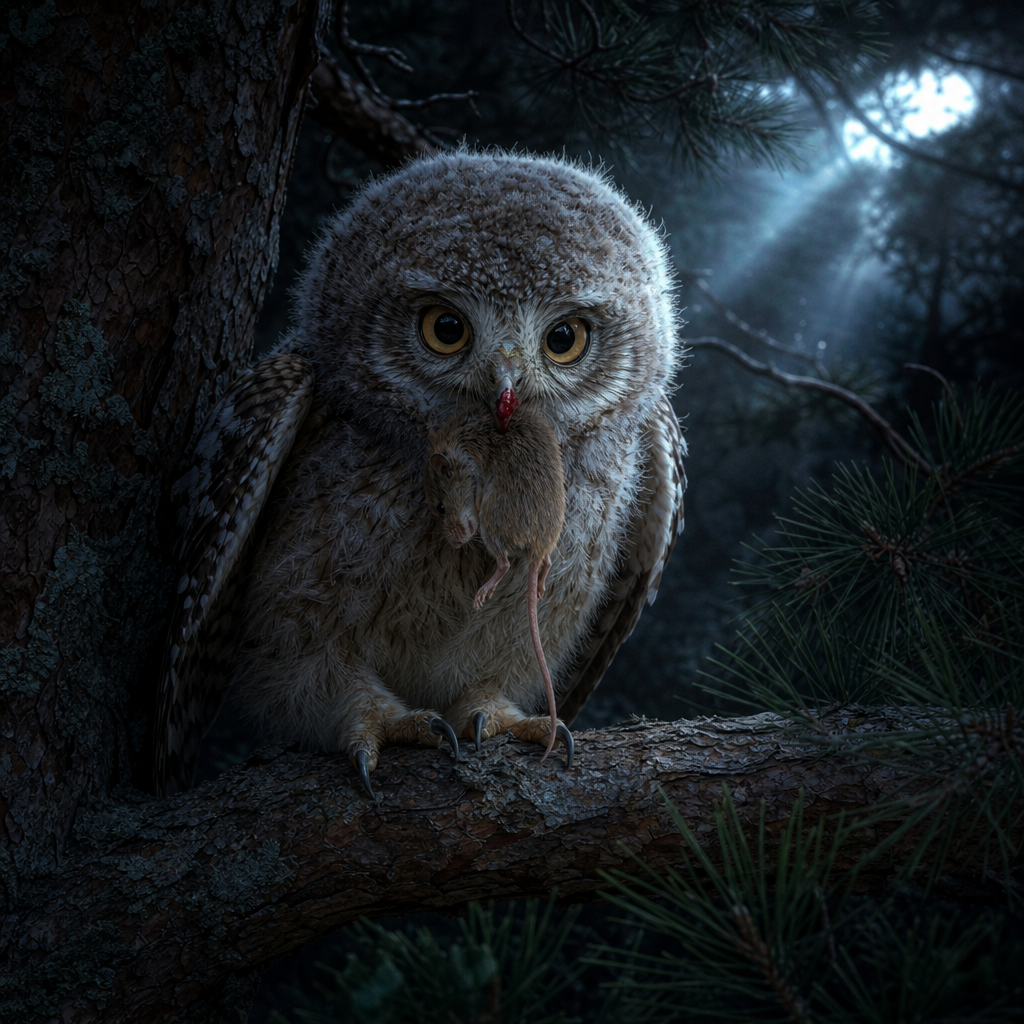

In [9]:
from IPython.display import display, HTML

image_base64 = response_image.json()['output']['image_base64']

HTML(f'<img src="data:image/png;base64,{image_base64}"/>')

測試生成後續後續的故事

In [10]:
response_next_tory = requests.post(
    "http://localhost:8080/story_telling/invoke",
    json={"input":{'scratch': "Create the next page content following the context",
                   'context': story_json['output']}
         }
)

In [11]:
next_chapter = response_next_tory.json()['output']

In [12]:
print(next_chapter)

The pine sap dripped like amber smoke onto the moss, and the scent of it rose, thick and sweet, mingling with the coppery tang of fresh blood that still clung to Talon's beak. A low, resonant hoot shattered the stillness—a voice older than the trunks around them, low and reverberating through bark and bone. The sound rolled through the canopy, a rolling tide of vibration that set the needles trembling.

Talon's feathers ruffled as the call pressed against his throat. He lowered his head, tasting iron on his tongue, and felt the soft, frantic pulse of the mouse's heart still thudding against his chest. The tiny creature's eyes, glossy and unfocused, reflected the fleeting moonlight before going still, the rhythm of life dimming to a single, final sigh.

A shadow shifted farther up the branch, the silhouette of a larger form slipping between the moss‑draped limbs. Silvery-gray feathers brushed against the bark, the wind catching the fringe of a massive wing. The new arrival—an elder owl,

根據故事和上一張圖片，產生出下一張圖片

透過requests送出base64 string.

本來是想要透過img2img的手法控制圖片風格和內容一致性的，但是發現不確定性很高，所以決定從上一張圖片的prompt下手，看看能不能調高一致性。

In [13]:
response = requests.post(
    "http://localhost:8080/image_generation/invoke",
    json={"input": {'story': next_chapter,
                    'style_reference':response_image.json()['output']['nl_prompt'],
                    'image_io': []
                   }
    }
)

In [14]:
response.json()['output']['nl_prompt']

'hyper‑realistic digital painting of a moonlit pine branch at night, the young owl Talon perched with ruffled dark feathers, his beak stained vivid ruby‑red from fresh blood, a tiny brown mouse slipping onto the pine needle carpet; beside him an elder owl with silvery‑gray, scar‑mottled plumage and amber, unblinking eyes settles, her massive wing fringe catching a thin silver moonbeam, both talons poised over the mouse; amber‑colored sap drips like smoke onto moss-covered bark, casting a warm glow that contrasts cool blue‑green shadows across the bark and needles; faint mist hangs in the air, detailed textures on feathers, bark, moss, and mouse fur, atmospheric and solemn mood.'


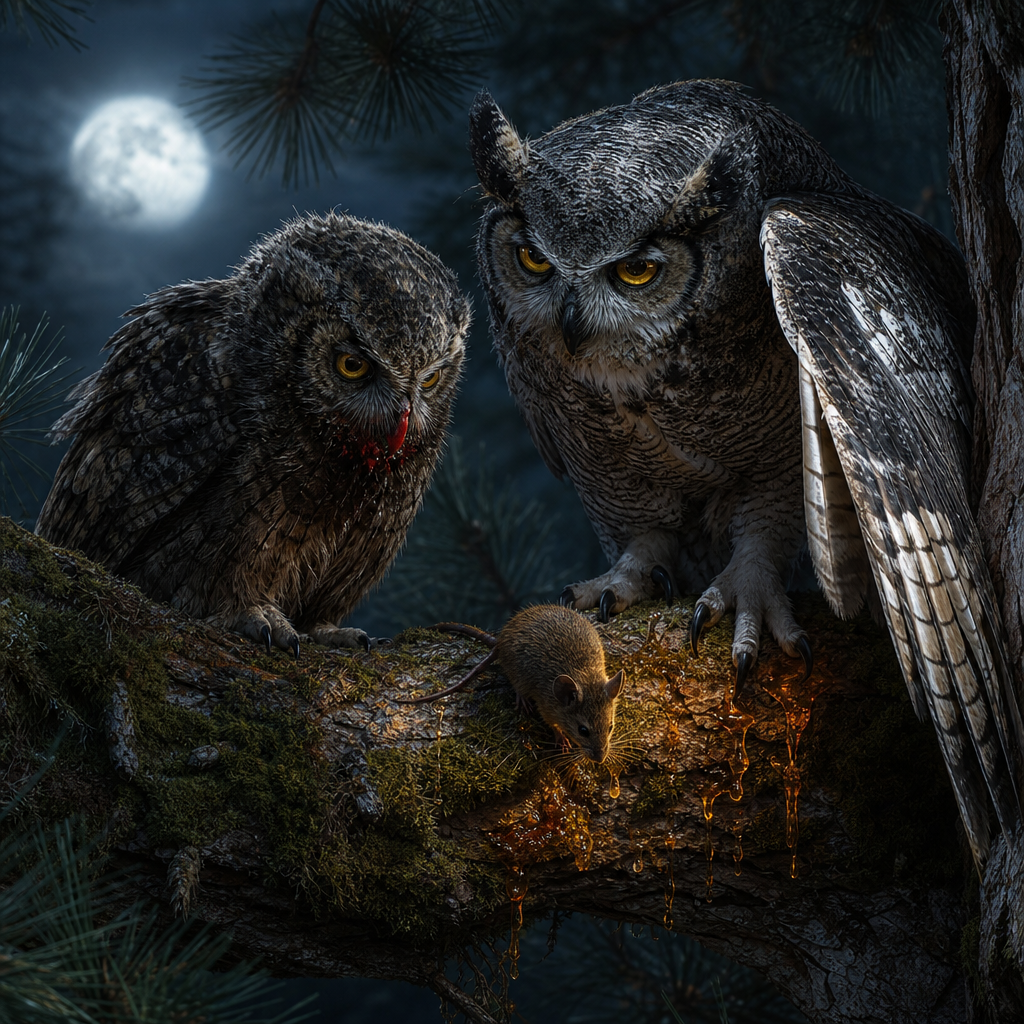

In [15]:
image_base64 = response.json()['output']['image_base64']

HTML(f'<img src="data:image/png;base64,{image_base64}"/>')

測試語音生成

In [19]:
response = requests.post(
    "http://localhost:8080/audio_generation/invoke",
    json={"input": {'audio_input': "How are you doing?"}}
)

In [20]:
response

<Response [200]>

In [21]:
import base64
from IPython.display import Audio

audio_bytes = base64.b64decode(response.json()['output'])

# 在 notebook 中播放
Audio(audio_bytes, autoplay=True)

## 生成工具模板

In [22]:
from pydantic import BaseModel, Field
from typing import Optional, List, Tuple, Callable, Any

from langchain.tools import BaseTool
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import FilePath


class ToolTemplate(BaseTool):
    """
    ToolTemplateHTTP 是一個通用工具模板，用於呼叫 LangServe REST API。

    # 功能概述
    - 將結構化輸入透過 PydanticOutputParser 驗證與格式化
    - 支援輸入前處理（input_data_processors）
    - 支援輸出後處理（output_data_processors）
    - 自動處理 HTTP 呼叫錯誤與回應驗證
    - 可整合 LangChain Agent 使用

    # 設計目的
    此工具用於標準化 LangServe API 呼叫流程，確保：
    1. 輸入格式一致且可驗證
    2. API 呼叫錯誤可追蹤
    3. 輸出可進一步加工或轉換
    4. 易於擴展不同工具與模型服務

    # 使用情境
    - 呼叫遠端 LLM / Image / Workflow service
    - 作為 Agent tool wrapper
    - 串接多階段 AI pipeline
    """

    runnable: str = Field(..., description="LangServe API endpoint URL")
    name: str = Field(..., description="Tool 名稱")
    input_parser: PydanticOutputParser = Field(..., description="輸入格式解析器（PydanticOutputParser）")

    description: str = Field(..., description="Tool 說明（包含輸入格式）")

    input_data_processors: Optional[List[Tuple[str, Callable[[Any], Any]]]] = Field(
        default=None,
        description="輸入資料前處理器 (field_name, function)"
    )

    output_data_processors: Optional[List[Tuple[Optional[str], Callable[[Any], Any]]]] = Field(
        default=None,
        description="輸出資料後處理器 (field_name, function)"
    )

    # =========================
    # 建立工具
    # =========================
    @classmethod
    def create(
        cls,
        runnable: str,
        name: str,
        description_template: str,
        input_parser: PydanticOutputParser,
        input_data_processors: Optional[List[Tuple[str, Callable[[Any], Any]]]] = None,
        output_data_processors: Optional[List[Tuple[Optional[str], Callable[[Any], Any]]]] = None,
    ):
        """
        建立 ToolTemplate 實例

        # 流程
        1. 從 input_parser 取得輸入格式規範
        2. 注入 description_template
        3. 回傳初始化完成的 Tool

        # Args
        - runnable: LangServe endpoint URL
        - name: tool 名稱
        - description_template: description 模板（需包含 {input_format_instruction}）
        - input_parser: PydanticOutputParser
        - input_data_processors: 輸入前處理函數列表
        - output_data_processors: 輸出後處理函數列表
        """

        input_format_instruction = input_parser.get_format_instructions()

        description = description_template.format(
            input_format_instruction=input_format_instruction
        )

        return cls(
            runnable=runnable,
            name=name,
            description=description,
            input_parser=input_parser,
            input_data_processors=input_data_processors,
            output_data_processors=output_data_processors,
        )

    # =========================
    # 同步執行
    # =========================
    def _run(self, **input_):
        """
        執行 Tool（同步版本）

        # 流程
        1. 印出 tool 呼叫資訊
        2. 套用 input processors（若有）
        3. 發送 HTTP request 到 LangServe
        4. 驗證 response 格式
        5. 更新 session_state（若存在）
        6. 套用 output processors
        7. 回傳結果

        # Args
        - **input_: Tool 輸入參數（dict）

        # Returns
        - filename（若存在）或 output dict
        """

        print(f"Call tool: {self.name}")
        
        runnable_inputs = input_.get('input_', input_)

        # -------------------------
        # 1. Input Pre-processing
        # -------------------------
        if self.input_data_processors:
            for field, fn in self.input_data_processors:
                if field in self.input_parser.pydantic_object.model_fields:
                    runnable_inputs[field] = fn(runnable_inputs[field]) 
        
        # 印出轉換過後的 runnable_inputs
        print(f"\n******\ninput: {runnable_inputs}\n******\n")
        
        # -------------------------
        # 2. HTTP Request
        # -------------------------
        try:
            response = requests.post(
                str(self.runnable),
                json={"input": runnable_inputs},
                timeout=240, # 圖像生成相當耗時
            )
            response.raise_for_status()
            result = response.json()

        except Exception as e:
            raise RuntimeError(
                f"Langserve call failed: {e}, inputs={runnable_inputs}"
            )

        # -------------------------
        # 3. Response Validation
        # -------------------------
        if "output" not in result:
            raise RuntimeError(f"Invalid response format from LangServe: {result}")

        output = result["output"]

        # -------------------------
        # 4. Session State Update
        # -------------------------
        for key in session_state.keys():
            if key in output:
                session_state[key] = output[key]
        
        # -------------------------
        # 5. Output Post-processing
        # -------------------------
        if self.output_data_processors:
            for field, fn in self.output_data_processors:
                if not field:
                    fn(output, runnable_inputs.get("filename"))
                else:
                    fn(output.get(field), runnable_inputs.get("filename"))

        # -------------------------
        # 6. Final Return
        # -------------------------
        filename = runnable_inputs.get("filename", output)
        return f"{self.name} returns filename: {filename}"

    # =========================
    # 非同步版本（未實作）
    # =========================
    def _arun(self, query: str):
        """
        非同步版本（目前未支援）

        Raises:
            NotImplementedError
        """
        raise NotImplementedError("This tool does not support async")

C:\Users\Ling\miniconda3\envs\aicg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### State Variables

用來追蹤 nl_prompt

因為第 N+1 張的圖片，需要依靠第 N 張圖片的提示詞來得知圖片風格。

In [23]:
session_state = {}

session_state['nl_prompt'] = None

In [24]:
from pathlib import Path
from textwrap import dedent
from typing import List

from pydantic import BaseModel, Field


class StoryInput(BaseModel):
    scratch: str = Field(
        description=dedent("""\
            The draft, notes, or rough idea for the current page of the story.
            （故事當前頁面的草稿、筆記或初步構想）
        """)
    )
    
    context: List[FilePath] = Field(
        default_factory=list,
        description=dedent("""\
            A list of previously generated .txt files that contain story content.  
            Used to maintain narrative consistency and continuity across images. If there are no previous results, return an empty list. 
            （先前生成的 .txt 檔案清單，其中包含故事內容。用於保持影像生成過程中的敘事一致性與連貫性。若沒有之前的內容，回傳空[]）
        """)
    )
    
    filename: str = Field(
        ...,
        description=dedent("""\
            The file path where the generated story text will be saved.
            （生成的故事文本將被儲存的檔案路徑）
        """)
    )


def export_to_txt(text, filename: Path):
    """
    將文字儲存為檔案。
    
    這樣 agent 就可以透過檔案名稱來記住前面的訊息，
    而不是每次都直接傳遞完整內容，藉此降低 token 使用量，
    以犧牲 I/O 效率換取成本節省。
    """

    print(f"export file to {filename}")

    # 取得目標檔案所在資料夾
    dir_ = Path(filename).parent

    # 若資料夾不存在則建立
    if not os.path.isdir(dir_):
        os.makedirs(dir_)

    # 將文字寫入檔案
    with open(filename, "w", encoding="utf-8") as file:
        file.write(text)


def read_from_txt(filename) -> str:
    """
    讀取單一文字檔內容
    """

    if "\n" in filename or len(filename) > 200:
        raise ValueError(
            f"Expected a file path to a .txt file, but received story text instead. "
            f"Pass the filename returned by Story-generation-tool, not the story content. "
            f"Received ({len(filename)} chars): {filename[:100]}..."
        )
    
    with open(filename, "r", encoding="utf-8") as file:
        content = file.read()

    return content


def read_from_list_of_text(filenames) -> str:
    """
    讀取多個文字檔案內容並合併

    用於取得先前生成的故事上下文，以維持敘事連貫性
    """

    return "\n\n".join([read_from_txt(f) for f in filenames])


# 對 context 欄位進行前處理：讀取所有歷史文本
story_input_data_processors = [
    ("context", read_from_list_of_text)
]


# ===================================================================
"""
input_data_processors 執行流程說明：

if self.input_data_processors:
    for field, fn in self.input_data_processors:
        if field in runnable_inputs:
            runnable_inputs[field] = fn(runnable_inputs[field])

邏輯：
1. 檢查 input_data_processors 是否存在
2. 逐一解構 (field, function)
3. 若該 field 存在於輸入資料中
   → 使用對應 function 進行轉換
4. 將轉換後結果覆蓋原欄位
"""
# ===================================================================


# 輸出處理：將生成文字寫入檔案
story_output_data_processors = [
    (None, export_to_txt)
]

story_telling_tool = ToolTemplate.create(
    runnable="http://localhost:8080/story_telling/invoke",
    name="Story-generation-tool",
    description_template=dedent("""\
        This tool is designed to generate a story one page at a time.
        
        Input format: {input_format_instruction}
    """),
    input_parser=PydanticOutputParser(pydantic_object=StoryInput),
    output_data_processors=story_output_data_processors,
    input_data_processors=story_input_data_processors
)

### 影像生成

In [25]:
class ImageInput(BaseModel):
    story: str = Field(
        description=dedent("""\
            The file name of the .txt file generated from the tool `Story-generation-tool`
        """)
    )
    
    # FilePath ensures the input path exists and is a valid file
    image_io: List[str] = Field(
        [],
        description=dedent("""\
            Path to the previously generated image.  Used in img2img generation to maintain visual and texture consistency. If there are no previous results, return an empty list. 
        """)
    )
    
    # Path allows flexibility: file may not exist yet but must be a valid path object.
    filename: str = Field(
        ...,
        description=dedent("""\
            Destination file path where the generated image will be saved.  
        """)
    )

    style_reference: str = Field("", description="圖片風格參考。將從state variable中取得，直接判定為空值。")


def image_to_base64(image_path):
    """
    將圖片檔案轉換為 Base64 字串
    """

    with Image.open(image_path) as image:

        # 將圖片暫存到記憶體 buffer
        buffered = io.BytesIO()
        image.save(buffered, format="JPEG")

        # 將圖片內容編碼為 Base64
        image_str = base64.b64encode(buffered.getvalue())

    return image_str.decode('utf-8')


def image_to_base64_from_list(filenames: List[str]) -> List[Optional[str]]:
    """
    將多個圖片路徑轉換為 Base64 字串列表
    （目前尚未實作完整邏輯）
    """

    # return [image_to_base64(f) for f in filenames]
    return []


def export_to_image(content: str, filename: str):
    """
    將 Base64 字串 (content) 解碼並儲存為圖片檔案 (filename)
    """

    # 取得檔案所在資料夾
    dir_ = Path(filename).parent

    # 若資料夾不存在則建立
    if not os.path.isdir(dir_):
        os.makedirs(dir_)

    # 將 Base64 解碼為 bytes
    image_bytes = base64.b64decode(content)

    # 寫入圖片檔案
    with open(filename, "wb") as fh:
        fh.write(image_bytes)

    
def style_adaptation(nl_prompt: str = ""):

    if session_state['nl_prompt']:
        return session_state['nl_prompt']
    else:
        return ""


def story_adaptation(story: str):
      # 如果傳進來的是故事內文而非檔案路徑，拋出明確錯誤
      if '\n' in story or len(story) > 200:
          raise ValueError(
              f"Expected a file path to a .txt file, but received story text instead. "
              f"Pass the filename returned by Story-generation-tool, not the story content."
          )
      story = read_from_txt(story)
    
      return story


# 輸出資料處理器：將 base64 轉存為圖片
image_output_data_processors = [
    ('image_base64', export_to_image)
]

# 輸入資料處理器：
# - story: 進行故事適配與補強
# - image_io: 將圖片路徑轉為 base64（用於 img2img）
image_input_data_processors = [
    ("image_io", image_to_base64_from_list),
    ("style_reference", style_adaptation),
    ("story", story_adaptation)
]

# 建立圖片生成工具
image_tool = ToolTemplate.create(
    runnable="http://localhost:8080/image_generation/invoke",
    name="Image-generation-tool",
    description_template=dedent("""\
        此工具用於根據敘事內容生成對應的影像。
        
        Input format: {input_format_instruction}
    """),
    input_parser=PydanticOutputParser(pydantic_object=ImageInput),
    output_data_processors=image_output_data_processors,
    input_data_processors=image_input_data_processors
)

### 語音生成

In [26]:
class AudioInput(BaseModel):
    audio_input: str = Field(...,
        description=dedent("""\
            The file name of the .txt file generated from the tool `Story-generation-tool`, whose content will be used to generate the audio content with text-to-speech (TTS).  
        """)
    )
    
    # Path allows flexibility: file may not exist yet but must be a valid path object.
    filename: str = Field(
        ...,
        description=dedent("""\
            Destination mp3 file path where the generated audio will be saved.  
        """)
    )

def export_to_audio(content, filename):
    """
    將 Base64 編碼的音訊內容解碼並儲存為 mp3 檔案
    """

    # 取得輸出檔案資料夾
    dir_ = Path(filename).parent

    # 若資料夾不存在則建立
    if not os.path.isdir(dir_):
        os.makedirs(dir_)

    # Base64 解碼為 audio bytes
    audio_bytes = base64.b64decode(content)

    # 寫入 mp3 檔案
    with open(filename, "wb") as fh:
        fh.write(audio_bytes)


# 輸出資料處理器：將 Base64 audio 寫入 mp3 檔
audio_output_data_processors = [
    (None, export_to_audio)
]


# 直接借用 story 的讀檔函數作為 TTS 輸入前處理
audio_input_data_processors = [
    ("audio_input", read_from_txt)
]


"""
audio_generation 中使用 `input` 這個欄位作為 TTS 輸入：

def tts_synthesizer(kwargs):

    response = client.audio.speech.create(
        model=model,
        voice=voice,
        input=kwargs['audio_input'],
        instructions=instructions
    )

    # 取得 audio bytes
    audio_data = response.read()

    # 編碼成 base64 以便 JSON 傳輸
    audio_b64 = base64.b64encode(audio_data).decode("utf-8")

    return audio_b64
"""


audio_tool = ToolTemplate.create(
    runnable="http://localhost:8080/audio_generation/invoke",
    name="Audio-generation-tool",
    description_template=dedent("""\
        此工具用於根據敘事內容生成對應的 mp3 語音檔。

        Input format: {input_format_instruction}
    """),
    input_parser=PydanticOutputParser(pydantic_object=AudioInput),
    output_data_processors=audio_output_data_processors,
    input_data_processors=audio_input_data_processors
)

In [27]:
from textwrap import dedent

from langchain.agents import create_agent
from langchain_ollama import ChatOllama
from langchain.agents.middleware.tool_retry import ToolRetryMiddleware

AGENT_SYSTEM_PROMPT = dedent("""\
# Role
You are the Audiobook Production Agent -- a disciplined, multi-modal content generator that produces synchronized story pages one at a time.

# Goal
For each page, reliably produce one refined story text, one matching illustration, and one narrated audio file, all aligned in content, tone, and filename.

# Toolset
You have access to three tools. Each tool expects the following inputs:

## 1. Story-generation-tool
Generates and refines the narrative text for the current page.
Inputs:
- `scratch` (str): The draft, notes, or rough idea for the current page.
- `context` (List[str]): File paths of all previously generated .txt files. Pass an empty list [] for the first page.
- `filename` (str): Output file path where the generated .txt will be saved.

Returns: a filename (str) -- the path to the generated .txt file. Use this exact filename as input to the next two tools.

## 2. Image-generation-tool
Generates a visual illustration matching the current story page.
Inputs:
- `story` (str): **MUST be the exact filename returned by Story-generation-tool** (e.g., "tutorial/week_8/story_test/page_02.txt"). Do NOT pass the story text itself -- the tool reads the file internally.
- `image_io` (List[str]): File paths of previously generated images for visual consistency. Pass an empty list [] for the first page.
- `filename` (str): Output file path where the generated .png will be saved.
- `style_reference` (str): Style guidance from a previous image prompt. Pass an empty string "" if unavailable.

## 3. Audio-generation-tool
Generates narration audio via TTS from the story text.
Inputs:
- `audio_input` (str): **MUST be the exact filename returned by Story-generation-tool** (e.g., "tutorial/week_8/story_test/page_02.txt"). Do NOT pass the story text itself -- the tool reads the file internally.
- `filename` (str): Output file path where the generated .mp3 will be saved.

# Execution Order (CRITICAL)
You MUST follow this pipeline strictly, one tool per step:

Step 1: Story-generation-tool
Step 2: Image-generation-tool
Step 3: Audio-generation-tool

- NEVER call Image or Audio tools before Story-generation-tool has completed.
- NEVER skip a step.
- NEVER call multiple tools in a single action.

# File Naming Convention
All three outputs for a single page MUST share the same base filename.

Base directory: tutorial/week_8/story_test

Example for page 01:
- tutorial/week_8/story_test/page_01.txt
- tutorial/week_8/story_test/page_01.png
- tutorial/week_8/story_test/page_01.mp3

# Context Management
- Always pass all previous .txt file paths into `context` to preserve narrative continuity.
- Image and audio tools must reference the latest story .txt file, NOT the draft scratch text.
- For Image-generation-tool, pass previous image paths into `image_io` to maintain visual consistency across pages.

# Constraints
- Do NOT generate image or audio without a finalized story file.
- Do NOT break the execution order under any circumstance.
- Do NOT pass raw story text to Image-generation-tool or Audio-generation-tool. Always pass the filename (str) returned by Story-generation-tool.
- Do NOT skip context from prior pages when generating a new page.
- Keep each page focused on one coherent scene or moment.

# Reasoning (Chain of Thought)
Before each tool call, think through:
Step 1: [Story Planning] What should this page cover? How does it connect to prior context?
Step 2: [Image Planning] What is the key visual moment? Does it match the finalized story?
Step 3: [Audio Planning] What tone and pacing suit this page's mood?

""")

tools = [story_telling_tool, image_tool, audio_tool]

model = ChatOllama(model='deepseek-v4-pro:cloud',
                   base_url='https://ollama.com',
                   name='agent', temperature=0)

agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=AGENT_SYSTEM_PROMPT,
    name = "audio_book_agent",
    middleware=[
        ToolRetryMiddleware(max_retries=2)]
)

In [29]:
import base64

from langchain.messages import HumanMessage

session_state = {}

session_state['nl_prompt'] = None

query = dedent("""
產生關於一個小男孩去參加西洋棋比賽的第一個章節。使用水彩風格。使用繁體中文回應。
""")

for update in agent.stream(
    {"messages": {"role": "user", "content": query}},
    stream_mode="updates",
):
    print(update)

{'model': {'messages': [AIMessage(content='# 第一章：西洋棋比賽 — 第 1 頁\n\n讓我按照流程逐步生成。首先從故事文本開始。\n\n---\n\n## 步驟 1：故事生成\n\n**思考：** 第一頁應該介紹主角——一個熱愛西洋棋的小男孩，以及他即將參加比賽的早晨。要營造期待與緊張的氛圍，為後續故事鋪墊。', additional_kwargs={}, response_metadata={'model': 'deepseek-v4-pro:cloud', 'created_at': '2026-08-01T07:27:06.450384989Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7554134716, 'load_duration': None, 'prompt_eval_count': 2294, 'prompt_eval_duration': None, 'eval_count': 391, 'eval_duration': None, 'logprobs': None, 'model_name': 'deepseek-v4-pro:cloud', 'model_provider': 'ollama'}, name='audio_book_agent', id='lc_run--019fbc37-e423-7130-b905-b52fbb54fc03-0', tool_calls=[{'name': 'Story-generation-tool', 'args': {}, 'id': '0e6c3e0a-ae28-49c7-99e0-304d36689d44', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2294, 'output_tokens': 391, 'total_tokens': 2685})]}}
Call tool: Story-generation-tool
Call tool: Story-generation-tool
Call tool: Story-generation-tool
{'tools'

In [30]:
from pydub import AudioSegment

# 播放 (simple, blocking)
sound = AudioSegment.from_mp3("tutorial/week_8/story_test/page_01.mp3")

sound

成功的生成了一頁的內容，Agent可以幫我們生成整個故事嗎?

In [31]:
import shutil

shutil.rmtree("tutorial/week_8/story_test")

In [32]:
for update in agent.stream(
    {"messages": {"role": "user", "content": "產生關於一個小男孩去參加西洋棋比賽的故事。使用水彩風格。一共四頁。使用繁體中文回應"}},
    stream_mode="updates",
):
    print(update)

{'model': {'messages': [AIMessage(content='好的！我將為你創作一個四頁的西洋棋比賽故事。讓我們從第一頁開始。\n\n---\n\n## 📖 第一頁：故事的開端\n\n**Step 1：生成故事文本**', additional_kwargs={}, response_metadata={'model': 'deepseek-v4-pro:cloud', 'created_at': '2026-08-01T07:33:02.50467336Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3701174767, 'load_duration': None, 'prompt_eval_count': 2293, 'prompt_eval_duration': None, 'eval_count': 371, 'eval_duration': None, 'logprobs': None, 'model_name': 'deepseek-v4-pro:cloud', 'model_provider': 'ollama'}, name='audio_book_agent', id='lc_run--019fbc3d-6228-77b2-b5cb-3b0e9bfd468b-0', tool_calls=[{'name': 'Story-generation-tool', 'args': {'input_': {'context': [], 'filename': 'tutorial/week_8/story_test/page_01.txt', 'scratch': '第一頁：小男孩叫小宇，今年八歲，他非常喜歡下西洋棋。這天清晨，陽光透過窗簾灑進房間，小宇坐在書桌前，專注地看著面前的西洋棋盤。他手裡握著一隻白色的騎士棋子，眼神堅定。今天是他第一次參加正式的西洋棋比賽，他既緊張又興奮。媽媽在門口微笑看著他，提醒他該出發了。小宇深吸一口氣，把騎士放進棋盒，準備迎接挑戰。'}}, 'id': 'a75263a4-d20a-4578-8ca3-174697c6a45a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_

KeyboardInterrupt: 

In [ ]:
result

### 影片輸出

In [33]:
from glob import glob

base_dir = os.path.join("tutorial/week_8/story_test")

images = glob(f"{base_dir}/*.png")
audios = glob(f"{base_dir}/*.mp3")

確定順序的正確性，不然就要靠sort或是其他的方法。

In [34]:
audios

['tutorial/week_8/story_test\\page_01.mp3',
 'tutorial/week_8/story_test\\page_02.mp3',
 'tutorial/week_8/story_test\\page_03.mp3']

In [35]:
images

['tutorial/week_8/story_test\\page_01.png',
 'tutorial/week_8/story_test\\page_02.png',
 'tutorial/week_8/story_test\\page_03.png']

In [ ]:
!pip install moviepy

In [36]:
from moviepy import ImageClip, AudioFileClip, concatenate_videoclips

video_clips = []

buffer_seconds = 2

for img_path, aud_path in zip(images, audios):

    audio_clip = AudioFileClip(aud_path)
    total_duration = audio_clip.duration + buffer_seconds

    # 2. Create image clip and set duration to match the audio
    img_clip = ImageClip(img_path).with_duration(total_duration)
    img_clip = img_clip.with_audio(audio_clip)

    video_clips.append(img_clip)

print("Concatenating all clips into final video... (this may take a few minutes)")
final_video = concatenate_videoclips(video_clips, method="chain")

# Write the final file
output_filename = "tutorial/week_8/audio_book_template.mp4"

final_video.write_videofile(output_filename, fps=24, codec="libx264", audio_codec="aac",  preset="ultrafast")

Concatenating all clips into final video... (this may take a few minutes)
MoviePy - Building video tutorial/week_8/audio_book_template.mp4.
MoviePy - Writing audio in audio_book_templateTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video tutorial/week_8/audio_book_template.mp4



MoviePy - Done !
MoviePy - video ready tutorial/week_8/audio_book_template.mp4


In [37]:
from IPython.display import Video
from IPython.display import HTML

HTML("""
<video width="600" controls>
  <source src="audio_book.mp4" type="video/mp4">
</video>
""")

## 🎧 互動式有聲書內容生成

- 不一定需要完整的 **Agent 架構**，因為流程的每一步（故事 → 圖像 → 語音）都已經明確定義，能由使用者主動觸發。  
- 可以直接基於 **聊天機器人** 的互動形式進行，每次輸入使用者的需求或指令後，系統依照指定步驟生成對應內容。  
- 使用者可以在故事生成過程中即時調整方向，例如指定角色、情節走向或語氣，提升 **客製化體驗**。  
- 這種互動方式非常適合 **語言學習** 場景：  
  - 學習者能一邊閱讀故事、一邊聽有聲輸出  
  - 可即時修改故事情節，產生更貼近學習需求的內容  
  - 搭配圖片與語音，提升沉浸式學習效果  